In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

pd.set_option('display.max_columns', 50)

df = pd.read_csv('ecommerce_customer_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [3]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values per column:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Duplicate rows: 0


In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values per column:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Duplicate rows: 0


In [5]:
target_counts = df['Subscription Status'].value_counts()
target_pct = df['Subscription Status'].value_counts(normalize=True) * 100
print(target_counts)
print(target_pct.round(2))

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64
Subscription Status
No     73.0
Yes    27.0
Name: proportion, dtype: float64


In [6]:
# Check for two data-quality artifacts worth documenting before modelling
print('Discount Applied vs Promo Code Used are identical for every row:',
      (df['Discount Applied'] == df['Promo Code Used']).mean())

print()
print('Subscription Status by Gender:')
print(pd.crosstab(df['Gender'], df['Subscription Status']))

print()
print('Subscription Status by Discount Applied:')
print(pd.crosstab(df['Discount Applied'], df['Subscription Status']))

Discount Applied vs Promo Code Used are identical for every row: 1.0

Subscription Status by Gender:
Subscription Status    No   Yes
Gender                         
Female               1248     0
Male                 1599  1053

Subscription Status by Discount Applied:
Subscription Status    No   Yes
Discount Applied               
No                   2223     0
Yes                   624  1053


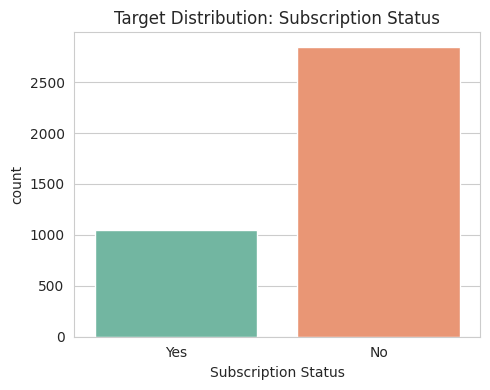

In [7]:
fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(data=df, x='Subscription Status', ax=ax, palette='Set2')
ax.set_title('Target Distribution: Subscription Status')
plt.tight_layout()
plt.show()

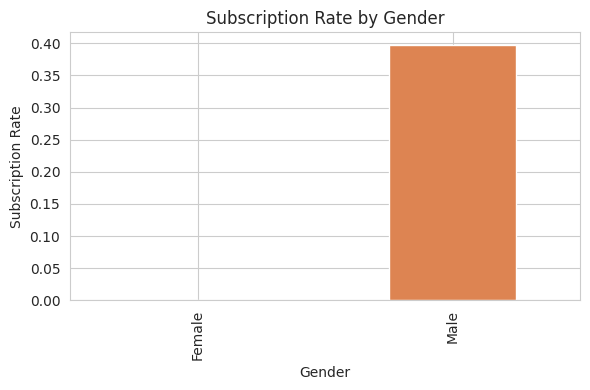

In [8]:
fig, ax = plt.subplots(figsize=(6,4))
sub_by_gender = df.groupby('Gender')['Subscription Status'].apply(lambda s: (s=='Yes').mean())
sub_by_gender.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.set_ylabel('Subscription Rate')
ax.set_title('Subscription Rate by Gender')
plt.tight_layout()
plt.show()

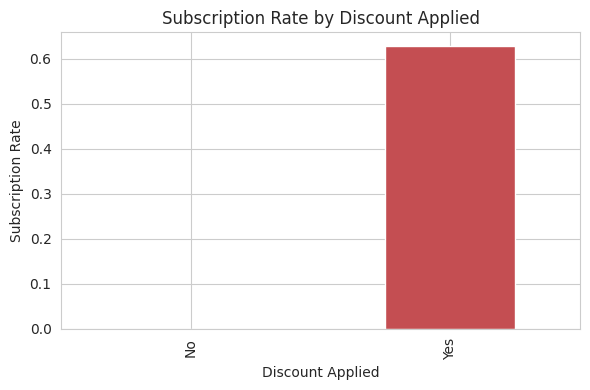

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
sub_by_discount = df.groupby('Discount Applied')['Subscription Status'].apply(lambda s: (s=='Yes').mean())
sub_by_discount.plot(kind='bar', ax=ax, color=['#55A868','#C44E52'])
ax.set_ylabel('Subscription Rate')
ax.set_title('Subscription Rate by Discount Applied')
plt.tight_layout()
plt.show()

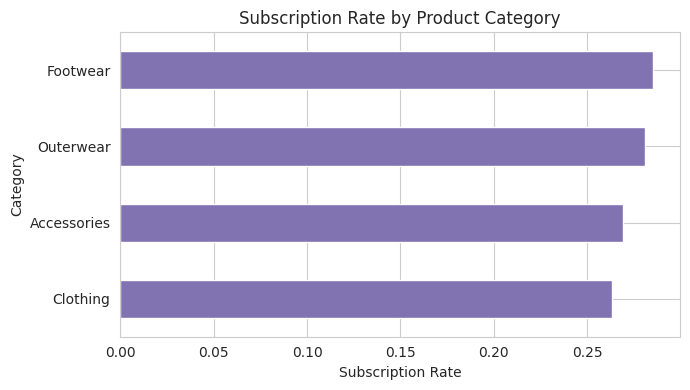

In [10]:
fig, ax = plt.subplots(figsize=(7,4))
sub_by_cat = df.groupby('Category')['Subscription Status'].apply(lambda s: (s=='Yes').mean()).sort_values()
sub_by_cat.plot(kind='barh', ax=ax, color='#8172B2')
ax.set_xlabel('Subscription Rate')
ax.set_title('Subscription Rate by Product Category')
plt.tight_layout()
plt.show()

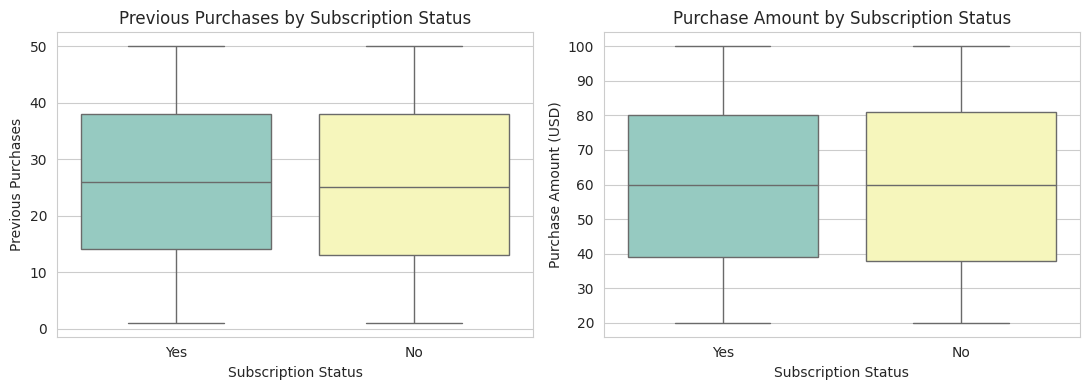

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.boxplot(data=df, x='Subscription Status', y='Previous Purchases', ax=axes[0], palette='Set3')
axes[0].set_title('Previous Purchases by Subscription Status')
sns.boxplot(data=df, x='Subscription Status', y='Purchase Amount (USD)', ax=axes[1], palette='Set3')
axes[1].set_title('Purchase Amount by Subscription Status')
plt.tight_layout()
plt.show()

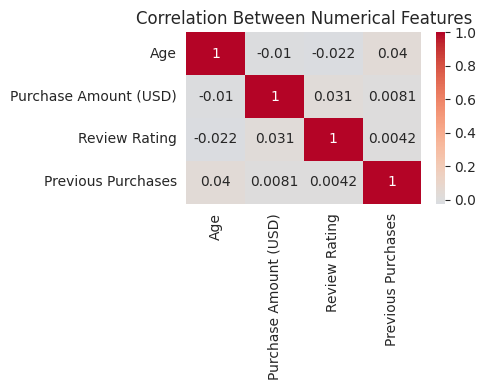

In [12]:
numerical_cols_for_corr = ['Age','Purchase Amount (USD)','Review Rating','Previous Purchases']
corr = df[numerical_cols_for_corr].corr()
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Between Numerical Features')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

work_df = df.drop_duplicates().copy()
work_df['Subscription Status'] = work_df['Subscription Status'].map({'Yes': 1, 'No': 0})
work_df = work_df.drop(columns=['Customer ID', 'Promo Code Used'])

y = work_df['Subscription Status']
X = work_df.drop(columns=['Subscription Status'])

numerical_columns = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
categorical_columns = [c for c in X.columns if c not in numerical_columns]

print('Numerical columns:', numerical_columns)
print('Categorical columns:', categorical_columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train purchase rate:', y_train.mean().round(4), ' Test purchase rate:', y_test.mean().round(4))

Numerical columns: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
Categorical columns: ['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Shipping Type', 'Discount Applied', 'Payment Method', 'Frequency of Purchases']
Train shape: (3120, 15)  Test shape: (780, 15)
Train purchase rate: 0.2699  Test purchase rate: 0.2705


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numerical_columns),
    ('cat', categorical_pipeline, categorical_columns)
])

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay)

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

fitted_pipelines = {}
comparison_rows = []

for name, clf in baseline_models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    comparison_rows.append({
        'Model': name,
        'Optimization Status': 'Baseline',
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

baseline_results = pd.DataFrame(comparison_rows)
baseline_results

,Model,Optimization Status,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,Baseline,0.853846,0.685824,0.848341,0.758475,0.909794
1,Decision Tree,Baseline,0.791026,0.634831,0.535545,0.580977,0.710655
2,Random Forest,Baseline,0.843590,0.663004,0.857820,0.747934,0.906917


In [17]:
for name, pipe in fitted_pipelines.items():
    preds = pipe.predict(X_test)
    print(f'--- {name} ---')
    print(classification_report(y_test, preds))
    print('Confusion matrix:\n', confusion_matrix(y_test, preds))
    print()

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.94      0.86      0.90       569
           1       0.69      0.85      0.76       211

    accuracy                           0.85       780
   macro avg       0.81      0.85      0.83       780
weighted avg       0.87      0.85      0.86       780

Confusion matrix:
 [[487  82]
 [ 32 179]]

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       569
           1       0.63      0.54      0.58       211

    accuracy                           0.79       780
   macro avg       0.74      0.71      0.72       780
weighted avg       0.78      0.79      0.79       780

Confusion matrix:
 [[504  65]
 [ 98 113]]

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       569
           1       0.66      0.86      0.75       211

    accuracy            

In [18]:
from sklearn.model_selection import GridSearchCV

lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', LogisticRegression(max_iter=2000, random_state=42))])
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__class_weight': [None, 'balanced']
}
lr_search = GridSearchCV(lr_pipeline, lr_param_grid, scoring='f1', cv=5, n_jobs=-1)
lr_search.fit(X_train, y_train)

print('Logistic Regression best params:', lr_search.best_params_)
print('Logistic Regression best CV F1:', lr_search.best_score_.round(4))

Logistic Regression best params: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}
Logistic Regression best CV F1: 0.7648


In [19]:
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', RandomForestClassifier(random_state=42))])
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__class_weight': [None, 'balanced']
}
rf_search = GridSearchCV(rf_pipeline, rf_param_grid, scoring='f1', cv=5, n_jobs=-1)
rf_search.fit(X_train, y_train)

print('Random Forest best params:', rf_search.best_params_)
print('Random Forest best CV F1:', rf_search.best_score_.round(4))

Random Forest best params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Random Forest best CV F1: 0.7648


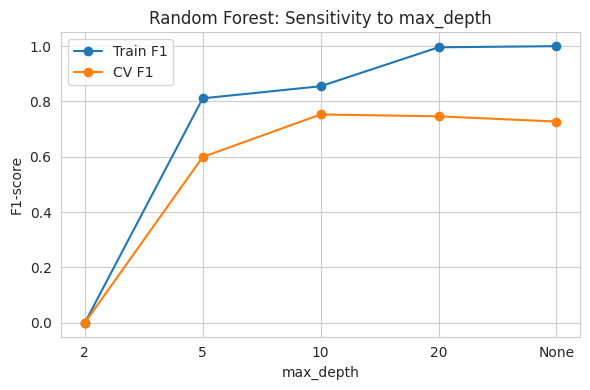

In [20]:
from sklearn.model_selection import validation_curve

depth_range = [2, 5, 10, 20, None]
depth_labels = [str(d) for d in depth_range]
train_scores, test_scores = validation_curve(
    rf_pipeline, X_train, y_train,
    param_name='classifier__max_depth', param_range=depth_range,
    scoring='f1', cv=5, n_jobs=-1
)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(depth_labels, train_scores.mean(axis=1), marker='o', label='Train F1')
ax.plot(depth_labels, test_scores.mean(axis=1), marker='o', label='CV F1')
ax.set_xlabel('max_depth')
ax.set_ylabel('F1-score')
ax.set_title('Random Forest: Sensitivity to max_depth')
ax.legend()
plt.tight_layout()
plt.show()

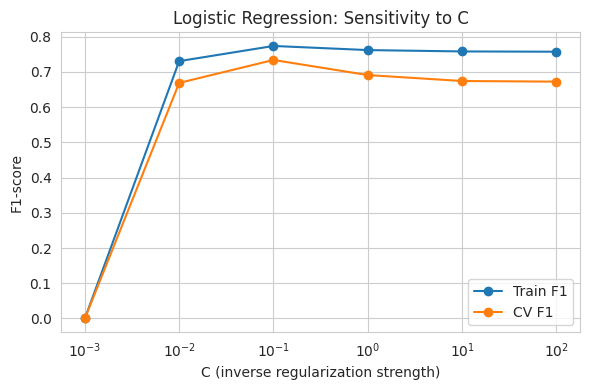

In [21]:
c_range = [0.001, 0.01, 0.1, 1, 10, 100]
train_scores_c, test_scores_c = validation_curve(
    lr_pipeline, X_train, y_train,
    param_name='classifier__C', param_range=c_range,
    scoring='f1', cv=5, n_jobs=-1
)

fig, ax = plt.subplots(figsize=(6,4))
ax.semilogx(c_range, train_scores_c.mean(axis=1), marker='o', label='Train F1')
ax.semilogx(c_range, test_scores_c.mean(axis=1), marker='o', label='CV F1')
ax.set_xlabel('C (inverse regularization strength)')
ax.set_ylabel('F1-score')
ax.set_title('Logistic Regression: Sensitivity to C')
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
optimized_candidates = {
    'Optimized Logistic Regression': lr_search.best_estimator_,
    'Optimized Random Forest': rf_search.best_estimator_
}

for name, model in optimized_candidates.items():
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    comparison_rows.append({
        'Model': name,
        'Optimization Status': 'Optimized',
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

full_comparison = pd.DataFrame(comparison_rows)
full_comparison

,Model,Optimization Status,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,Baseline,0.853846,0.685824,0.848341,0.758475,0.909794
1,Decision Tree,Baseline,0.791026,0.634831,0.535545,0.580977,0.710655
2,Random Forest,Baseline,0.843590,0.663004,0.857820,0.747934,0.906917
3,Optimized Logistic Regression,Optimized,0.864103,0.665615,1.000000,0.799242,0.909020
4,Optimized Random Forest,Optimized,0.864103,0.665615,1.000000,0.799242,0.909428


In [23]:
best_model = lr_search.best_estimator_
best_model_name = 'Optimized Logistic Regression'

optimized_predictions = best_model.predict(X_test)
optimized_probabilities = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, optimized_predictions))

              precision    recall  f1-score   support

           0       1.00      0.81      0.90       569
           1       0.67      1.00      0.80       211

    accuracy                           0.86       780
   macro avg       0.83      0.91      0.85       780
weighted avg       0.91      0.86      0.87       780



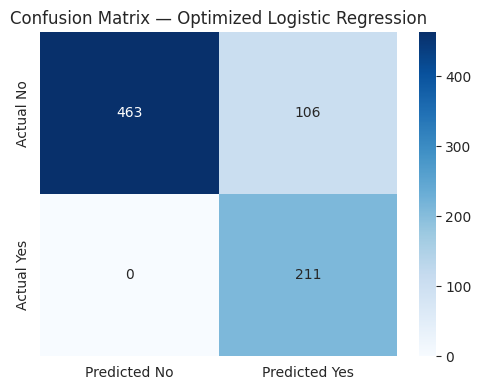

True Negatives: 463  False Positives: 106  False Negatives: 0  True Positives: 211


In [24]:
cm = confusion_matrix(y_test, optimized_predictions)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'], ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives: {tn}  False Positives: {fp}  False Negatives: {fn}  True Positives: {tp}')

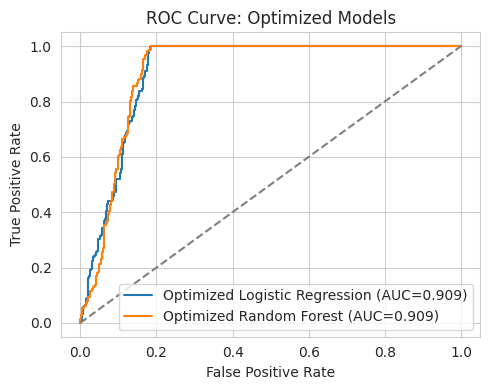

In [25]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(5,4))
for name, model in [('Optimized Logistic Regression', lr_search.best_estimator_),
                     ('Optimized Random Forest', rf_search.best_estimator_)]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1], [0,1], linestyle='--', color='grey')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Optimized Models')
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_model.named_steps['classifier'].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
feature_importance['AbsCoefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('AbsCoefficient', ascending=False)

top10 = feature_importance.head(10)
top10

,Feature,Coefficient,AbsCoefficient
124,cat__Discount Applied_No,-1.343397,1.343397
125,cat__Discount Applied_Yes,1.342513,1.342513
4,cat__Gender_Female,-0.480078,0.480078
5,cat__Gender_Male,0.479194,0.479194
121,cat__Shipping Type_Next Day Air,-0.079620,0.079620
8,cat__Item Purchased_Blouse,-0.079037,0.079037
3,num__Previous Purchases,0.066848,0.066848
119,cat__Shipping Type_Express,0.058523,0.058523
118,cat__Shipping Type_2-Day Shipping,-0.054288,0.054288
87,cat__Size_S,-0.052330,0.052330


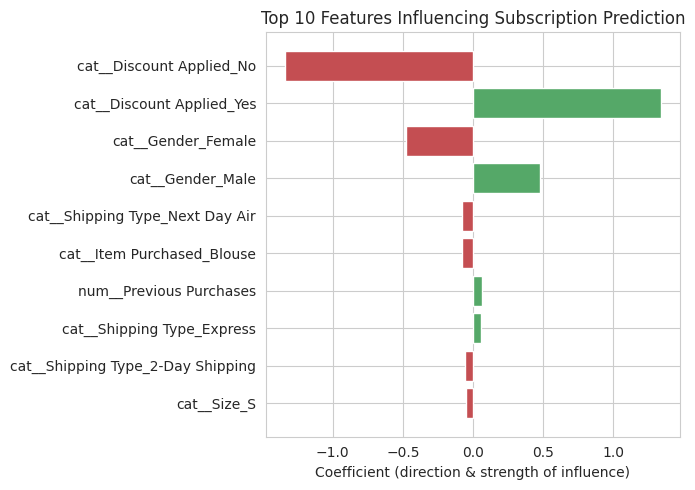

In [27]:
plot_df = top10.sort_values('AbsCoefficient')
colors = ['#C44E52' if c < 0 else '#55A868' for c in plot_df['Coefficient']]

fig, ax = plt.subplots(figsize=(7,5))
ax.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors)
ax.set_xlabel('Coefficient (direction & strength of influence)')
ax.set_title('Top 10 Features Influencing Subscription Prediction')
plt.tight_layout()
plt.show()

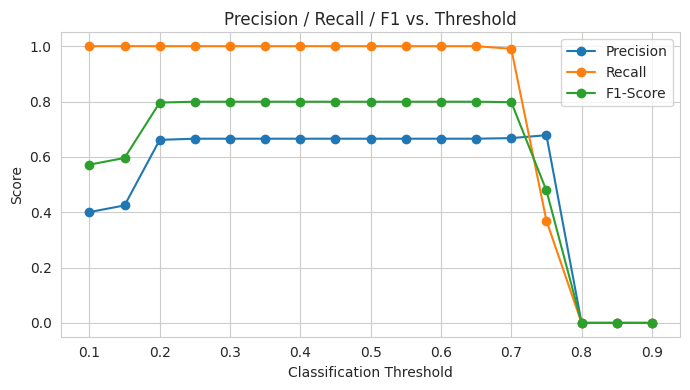

,Threshold,Precision,Recall,F1-Score
0,0.10,0.400380,1.000000,0.571816
1,0.15,0.424547,1.000000,0.596045
2,0.20,0.661442,1.000000,0.796226
3,0.25,0.665615,1.000000,0.799242
4,0.30,0.665615,1.000000,0.799242
5,0.35,0.665615,1.000000,0.799242
6,0.40,0.665615,1.000000,0.799242
7,0.45,0.665615,1.000000,0.799242
8,0.50,0.665615,1.000000,0.799242
9,0.55,0.665615,1.000000,0.799242


In [28]:
thresholds = np.arange(0.1, 0.95, 0.05)
threshold_rows = []
for t in thresholds:
    preds_t = (optimized_probabilities >= t).astype(int)
    threshold_rows.append({
        'Threshold': round(t, 2),
        'Precision': precision_score(y_test, preds_t, zero_division=0),
        'Recall': recall_score(y_test, preds_t, zero_division=0),
        'F1-Score': f1_score(y_test, preds_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='o', label='Recall')
ax.plot(threshold_df['Threshold'], threshold_df['F1-Score'], marker='o', label='F1-Score')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs. Threshold')
ax.legend()
plt.tight_layout()
plt.show()

threshold_df

In [29]:
segment_results = X_test.copy()
segment_results['ActualSubscription'] = y_test.values
segment_results['SubscriptionProbability'] = optimized_probabilities
segment_results['LikelihoodSegment'] = pd.cut(
    segment_results['SubscriptionProbability'],
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

segment_summary = segment_results.groupby('LikelihoodSegment').agg(
    Customers=('ActualSubscription', 'size'),
    ActualSubscriptionRate=('ActualSubscription', 'mean')
)
segment_summary

,Customers,ActualSubscriptionRate
LikelihoodSegment,,
Low,463,0.000000
Medium,0,NaN
High,317,0.665615


In [30]:
import joblib

joblib.dump(best_model, 'purchase_prediction_model.pkl')
print('Model saved to purchase_prediction_model.pkl')

Model saved to purchase_prediction_model.pkl
